In [1]:
import numpy as np
import pandas as pd
import pydicom
%matplotlib inline
import matplotlib.pyplot as plt
import keras 

Using TensorFlow backend.


In [9]:
# This function reads in a .dcm file, checks the important fields for our device, and returns a numpy array
# of just the imaging data
def check_dicom(filename): 
    # todo
    print('Load file {} ...'.format(filename))
    ds = pydicom.dcmread(filename)       
    if ((ds.Modality != 'DX') or (ds.PatientPosition not in ['AP', 'PA'])
        or (ds.BodyPartExamined != 'CHEST')):
        print('File {} is not suitable'.format(filename))
        return False
    img = ds.pixel_array
    return img
    

# This function takes the numpy array output by check_dicom and 
# runs the appropriate pre-processing needed for our model input
def preprocess_image(img, img_mean, img_std, img_size): 
    from skimage.transform import resize
    img = img.astype(np.float32)
    img = resize(img, (img_size[1], img_size[2]), preserve_range=True)
    img = (img - img_mean) / img_std
    img = np.expand_dims(img, axis=-1)  # Add channel
    img = np.repeat(img, 3, axis=-1)    # Make 3 channels
    img = np.expand_dims(img, axis=0)   # Add batch dimension
    return img

# This function loads in our trained model w/ weights and compiles it 
def load_model(model_path, weight_path):
    from tensorflow.keras.models import model_from_json
    with open(model_path, "r") as json_file:
        loaded_model_json = json_file.read()
    model = model_from_json(loaded_model_json)
    model.load_weights(weight_path)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# This function uses our device's threshold parameters to predict whether or not
# the image shows the presence of pneumonia using our trained model
def predict_image(model, img, thresh): 
    prob = model.predict(img)[0][0]
    pred = 1 if prob >= thresh else 0
    print(f"Predicted probability: {prob:.2f} — Predicted label: {pred}")
    return pred

In [12]:
test_dicoms = ['test1.dcm','test2.dcm','test3.dcm','test4.dcm','test5.dcm','test6.dcm']

model_path = "my_model.json"                # Path to model structure
weight_path = "xray_class_model.best.hdf5"  # Path to saved best weights

IMG_SIZE=(1,224,224,3) # This might be different if you did not use vgg16
img_mean = 128.0            # estimated mean from training preprocessing
img_std = 64.0              # estimated std from training preprocessing

my_model = load_model(model_path, weight_path) #loads model
thresh = 0.49   #loads the threshold they chose for model classification 

# use the .dcm files to test your prediction
for i in test_dicoms:
    img = check_dicom(i)
    if not isinstance(img, np.ndarray):
        continue
    img_proc = preprocess_image(img, img_mean, img_std, IMG_SIZE)
    pred = predict_image(my_model, img_proc, thresh)

Load file test1.dcm ...
Predicted probability: 0.44 — Predicted label: 0
Load file test2.dcm ...
Predicted probability: 0.42 — Predicted label: 0
Load file test3.dcm ...
Predicted probability: 0.51 — Predicted label: 1
Load file test4.dcm ...
File test4.dcm is not suitable
Load file test5.dcm ...
File test5.dcm is not suitable
Load file test6.dcm ...
File test6.dcm is not suitable


Load file test1.dcm ...
Load file test2.dcm ...
Load file test3.dcm ...
Load file test4.dcm ...
File test4.dcm is not suitable
Load file test5.dcm ...
File test5.dcm is not suitable
Load file test6.dcm ...
File test6.dcm is not suitable


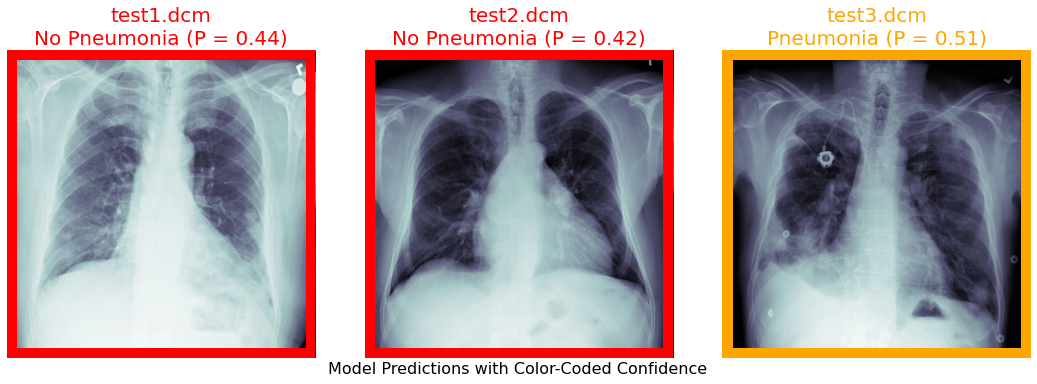

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Re-run and collect images + predictions
display_results = []

for filename in test_dicoms:
    img = check_dicom(filename)
    if isinstance(img, np.ndarray):
        img_proc = preprocess_image(img, img_mean, img_std, IMG_SIZE)
        prob = my_model.predict(img_proc)[0][0]
        pred_label = "Pneumonia" if prob >= thresh else "No Pneumonia"
        display_results.append((filename, img, prob, pred_label))

# Plot with color-coded titles and borders
n = len(display_results)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(5 * cols, 5 * rows))

for idx, (fname, img, prob, pred_label) in enumerate(display_results):
    ax = plt.subplot(rows, cols, idx + 1)
    ax.imshow(img, cmap='bone')

    # Determine color
    if prob >= 0.7 or prob <= 0.3:
        color = 'green'
    elif 0.45 < prob < 0.55:
        color = 'orange'
    else:
        color = 'red'

    # Draw border
    rect = Rectangle((0, 0), img.shape[1], img.shape[0],
                     linewidth=20, edgecolor=color, facecolor='none')
    ax.add_patch(rect)

    # Title
    ax.set_title(f"{fname}\n{pred_label} (P = {prob:.2f})", fontsize=20, color=color)
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Model Predictions with Color-Coded Confidence", fontsize=16, y=0.02)
plt.show()

#### Inference and Clinical Workflow Summary

A pipeline was developed to test the trained model on real-world DICOM files. Files were screened for valid metadata (DX modality, CHEST body part, PA/AP view), preprocessed, and classified using a threshold of 0.49.

Three out of six files were valid and processed. Predictions were printed with confidence scores.

As a bonus, a visual display of the predictions was created. This final visualization was not required but was added to enhance clarity and presentation.
